# Cifar Tests

This notebook runs fidelity tests on CIFAR-10 deep learning models.

This notebook is part of the experimental pipeline for the paper 'Where Can I Trust You? Teacher-Surrogate Disagreement is Spatially Structured'.

### High-Dimensional Fidelity Computation

We compute standard global fidelity (agreement on all CIFAR test points) and contrast it against our proposed confidence-weighted fidelity metric to see if the disparity persists in image data.

In [1]:
# CIFAR-10 modern benchmark experiment for spatially structured fidelity disagreement.
#
# Purpose:
#   Test whether the global-vs-local fidelity phenomenon survives in a modern
#   neural image-classification setting.
#
# Setup:
#   - Dataset: CIFAR-10
#   - Teacher: ResNet18
#   - Surrogates:
#       1. linear probe on teacher penultimate embeddings
#       2. small MLP on teacher penultimate embeddings
#       3. small CNN trained on images to mimic teacher hard labels
#       4. shallow CNN trained on images to mimic teacher hard labels
#
# Outputs:
#   - cifar_fidelity_results.csv
#   - cifar_fidelity_summary.csv
#   - cifar_confidence_bins.csv
#   - cifar_confidence_bins_summary.csv
#   - cifar_global_boundary_confidence_weighted.png
#   - cifar_confidence_stratified_fidelity.png
#   - cifar_surrogate_selection_table.csv


In [2]:
%pip install numpy pandas matplotlib scikit-learn torch torchvision tqdm -q



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### CIFAR-10 Data Loading & Augmentation

We use standard torchvision datasets to load CIFAR-10, applying basic normalization and horizontal flips to prepare the evaluation set for the deep teacher networks.

In [3]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from tqdm.auto import tqdm

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, TensorDataset

import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18


In [4]:
# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------

BASE_SEED = 42
random.seed(BASE_SEED)
np.random.seed(BASE_SEED)
torch.manual_seed(BASE_SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print("Using device:", DEVICE)

DATA_DIR = "./data"
ARTIFACT_DIR = "./cifar_artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# Keep this moderate so the notebook is runnable on CPU/MPS.
# Increase these later for a final paper run.
TRAIN_SUBSET_SIZE = 20000
TEST_SUBSET_SIZE = 10000
BATCH_SIZE = 128
NUM_WORKERS = 2

TEACHER_EPOCHS = 10
CNN_SURROGATE_EPOCHS = 6
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

# Boundary and weighting settings.
BOUNDARY_EPS = 0.10
ALPHA = 10.0
CONFIDENCE_BINS = np.linspace(0.0, 0.5, 11)


Using device: mps


### Visualization

Finally, we visualize the spatial structure of teacher-surrogate disagreement to demonstrate the impact of locality weighting.

In [5]:
# -----------------------------------------------------------------------------
# Reproducibility helpers
# -----------------------------------------------------------------------------

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def savefig(name):
    path = os.path.join(ARTIFACT_DIR, name)
    plt.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
    print(f"Saved {path}")

plt.style.use("default")
mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
})


In [6]:
# -----------------------------------------------------------------------------
# CIFAR-10 data
# -----------------------------------------------------------------------------

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

train_full = torchvision.datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=train_transform,
)

train_eval_full = torchvision.datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=eval_transform,
)

test_full = torchvision.datasets.CIFAR10(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=eval_transform,
)

rng = np.random.default_rng(BASE_SEED)
train_indices = rng.choice(len(train_full), size=min(TRAIN_SUBSET_SIZE, len(train_full)), replace=False)
test_indices = np.arange(min(TEST_SUBSET_SIZE, len(test_full)))

train_subset = Subset(train_full, train_indices)
train_eval_subset = Subset(train_eval_full, train_indices)
test_subset = Subset(test_full, test_indices)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
train_eval_loader = DataLoader(train_eval_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Train subset: {len(train_subset)}")
print(f"Test subset: {len(test_subset)}")


100%|██████████| 170M/170M [00:05<00:00, 33.0MB/s] 


Train subset: 20000
Test subset: 10000


### ResNet Teacher & Distilled Surrogate Training

We load a pre-trained ResNet-18 teacher model and train a lightweight CNN surrogate using a knowledge distillation objective (matching logits via KL-Divergence) to test fidelity in high-dimensional spaces.

In [7]:
# -----------------------------------------------------------------------------
# Teacher: ResNet18 adapted for CIFAR-10
# -----------------------------------------------------------------------------

class CIFARResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.model = resnet18(weights=None, num_classes=num_classes)
        # CIFAR images are 32x32, so use a smaller first convolution and remove maxpool.
        self.model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.model.maxpool = nn.Identity()

    def forward(self, x):
        return self.model(x)


def train_classifier(model, loader, epochs, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY, title="model"):
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        correct = 0
        total = 0

        pbar = tqdm(loader, desc=f"Training {title} epoch {epoch + 1}/{epochs}")
        for xb, yb in pbar:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()

            total_loss += float(loss.item()) * len(xb)
            preds = logits.argmax(dim=1)
            correct += int((preds == yb).sum().item())
            total += len(xb)
            pbar.set_postfix(loss=total_loss / total, acc=correct / total)

    return model


def evaluate_classifier(model, loader):
    model.eval()
    correct = 0
    total = 0
    losses = []
    loss_fn = nn.CrossEntropyLoss(reduction="sum")

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            logits = model(xb)
            loss = loss_fn(logits, yb)
            losses.append(float(loss.item()))
            preds = logits.argmax(dim=1)
            correct += int((preds == yb).sum().item())
            total += len(xb)

    return {
        "accuracy": correct / total,
        "loss": sum(losses) / total,
    }


In [8]:
teacher_path = os.path.join(ARTIFACT_DIR, "teacher_resnet18_cifar10.pt")

teacher = CIFARResNet18(num_classes=10)

if os.path.exists(teacher_path):
    print("Loading cached teacher:", teacher_path)
    teacher.load_state_dict(torch.load(teacher_path, map_location=DEVICE))
    teacher = teacher.to(DEVICE)
else:
    teacher = train_classifier(
        teacher,
        train_loader,
        epochs=TEACHER_EPOCHS,
        title="teacher ResNet18",
    )
    torch.save(teacher.state_dict(), teacher_path)
    print("Saved teacher:", teacher_path)

teacher_metrics = evaluate_classifier(teacher, test_loader)
teacher_metrics


Training teacher ResNet18 epoch 10/10: 100%|██████████| 157/157 [01:19<00:00,  1.97it/s, acc=0.832, loss=0.482]


Saved teacher: ./cifar_artifacts/teacher_resnet18_cifar10.pt


{'accuracy': 0.7815, 'loss': 0.6811313330173493}

In [9]:
# -----------------------------------------------------------------------------
# Extract teacher predictions and embeddings
# -----------------------------------------------------------------------------

class ResNetFeatureExtractor(nn.Module):
    def __init__(self, cifar_resnet):
        super().__init__()
        m = cifar_resnet.model
        self.features = nn.Sequential(
            m.conv1,
            m.bn1,
            m.relu,
            m.maxpool,
            m.layer1,
            m.layer2,
            m.layer3,
            m.layer4,
            m.avgpool,
        )
        self.fc = m.fc

    def forward(self, x):
        feats = self.features(x)
        feats = torch.flatten(feats, 1)
        logits = self.fc(feats)
        return logits, feats


feature_teacher = ResNetFeatureExtractor(teacher).to(DEVICE)
feature_teacher.eval()


def collect_teacher_outputs(loader):
    all_logits = []
    all_feats = []
    all_y = []

    with torch.no_grad():
        for xb, yb in tqdm(loader, desc="Collecting teacher outputs"):
            xb = xb.to(DEVICE)
            logits, feats = feature_teacher(xb)
            all_logits.append(logits.cpu())
            all_feats.append(feats.cpu())
            all_y.append(yb.cpu())

    logits = torch.cat(all_logits).numpy()
    feats = torch.cat(all_feats).numpy()
    y = torch.cat(all_y).numpy()

    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
    teacher_pred = probs.argmax(axis=1)
    teacher_conf = probs.max(axis=1)
    # Multiclass margin: difference between top-1 and top-2 probabilities.
    sorted_probs = np.sort(probs, axis=1)
    teacher_margin = sorted_probs[:, -1] - sorted_probs[:, -2]

    return {
        "logits": logits,
        "features": feats,
        "true_y": y,
        "teacher_probs": probs,
        "teacher_pred": teacher_pred,
        "teacher_conf": teacher_conf,
        "teacher_margin": teacher_margin,
    }

train_teacher_data = collect_teacher_outputs(train_eval_loader)
test_teacher_data = collect_teacher_outputs(test_loader)

print("Train feature shape:", train_teacher_data["features"].shape)
print("Test feature shape:", test_teacher_data["features"].shape)
print("Teacher test accuracy:", (test_teacher_data["teacher_pred"] == test_teacher_data["true_y"]).mean())


Train feature shape: (20000, 512)
Test feature shape: (10000, 512)
Teacher test accuracy: 0.7815


In [11]:
# -----------------------------------------------------------------------------
# Surrogate 1 and 2: feature-based surrogates trained to mimic teacher labels
# -----------------------------------------------------------------------------

X_train_feats = train_teacher_data["features"]
y_train_teacher = train_teacher_data["teacher_pred"]
X_test_feats = test_teacher_data["features"]
y_test_teacher = test_teacher_data["teacher_pred"]

feature_surrogates = {}

feature_surrogates["linear_probe"] = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, n_jobs=-1),
)

feature_surrogates["embedding_mlp"] = make_pipeline(
    StandardScaler(),
    MLPClassifier(
        hidden_layer_sizes=(128,),
        activation="relu",
        solver="adam",
        max_iter=500,
        random_state=BASE_SEED,
    ),
)

for name, model in feature_surrogates.items():
    print("Training feature surrogate:", name)
    model.fit(X_train_feats, y_train_teacher)


Training feature surrogate: linear_probe
Training feature surrogate: embedding_mlp


In [12]:
# -----------------------------------------------------------------------------
# Surrogate 3 and 4: image-based CNN surrogates trained to mimic teacher labels
# -----------------------------------------------------------------------------

class SmallCNNSurrogate(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)


class ShallowCNNSurrogate(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 24, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(24 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)


def make_teacher_label_dataset(base_eval_subset, teacher_pred_labels):
    # Materialize images once so image surrogates train against teacher labels.
    images = []
    for i in tqdm(range(len(base_eval_subset)), desc="Materializing surrogate train images"):
        xb, _ = base_eval_subset[i]
        images.append(xb)
    images = torch.stack(images)
    labels = torch.tensor(teacher_pred_labels, dtype=torch.long)
    return TensorDataset(images, labels)

surrogate_train_dataset_path = os.path.join(ARTIFACT_DIR, "surrogate_train_images.pt")

if os.path.exists(surrogate_train_dataset_path):
    print("Loading materialized surrogate image dataset")
    saved = torch.load(surrogate_train_dataset_path, map_location="cpu")
    surrogate_image_dataset = TensorDataset(saved["images"], saved["labels"])
else:
    surrogate_image_dataset = make_teacher_label_dataset(train_eval_subset, y_train_teacher)
    images_tensor, labels_tensor = surrogate_image_dataset.tensors
    torch.save({"images": images_tensor, "labels": labels_tensor}, surrogate_train_dataset_path)

surrogate_image_loader = DataLoader(
    surrogate_image_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
)

image_surrogate_specs = {
    "small_cnn": SmallCNNSurrogate,
    "shallow_cnn": ShallowCNNSurrogate,
}

image_surrogates = {}

for name, cls in image_surrogate_specs.items():
    path = os.path.join(ARTIFACT_DIR, f"{name}_surrogate.pt")
    model = cls(num_classes=10)
    if os.path.exists(path):
        print("Loading cached image surrogate:", name)
        model.load_state_dict(torch.load(path, map_location=DEVICE))
        model = model.to(DEVICE)
    else:
        model = train_classifier(
            model,
            surrogate_image_loader,
            epochs=CNN_SURROGATE_EPOCHS,
            title=name,
        )
        torch.save(model.state_dict(), path)
        print("Saved image surrogate:", path)
    image_surrogates[name] = model


Training small_cnn epoch 6/6: 100%|██████████| 157/157 [00:04<00:00, 34.74it/s, acc=0.751, loss=0.706]


Saved image surrogate: ./cifar_artifacts/small_cnn_surrogate.pt


Training shallow_cnn epoch 6/6: 100%|██████████| 157/157 [00:03<00:00, 42.18it/s, acc=0.743, loss=0.728]


Saved image surrogate: ./cifar_artifacts/shallow_cnn_surrogate.pt


In [13]:
# -----------------------------------------------------------------------------
# Surrogate prediction helpers
# -----------------------------------------------------------------------------

def predict_feature_surrogate(model, X):
    pred = model.predict(X)
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X)
    else:
        probs = None
    return pred, probs


def collect_image_surrogate_outputs(model, loader):
    model.eval()
    logits_all = []
    y_all = []
    with torch.no_grad():
        for xb, yb in tqdm(loader, desc="Collecting image surrogate outputs"):
            xb = xb.to(DEVICE)
            logits = model(xb)
            logits_all.append(logits.cpu())
            y_all.append(yb.cpu())
    logits = torch.cat(logits_all).numpy()
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
    pred = probs.argmax(axis=1)
    return pred, probs


In [14]:
# -----------------------------------------------------------------------------
# Fidelity metrics
# -----------------------------------------------------------------------------

def normalized_weighted_average(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights >= 0)
    if valid.sum() == 0 or weights[valid].sum() == 0:
        return np.nan
    return float(np.sum(values[valid] * weights[valid]) / np.sum(weights[valid]))


def multiclass_confidence_weights(margin, alpha=ALPHA):
    # Boundary-like points have small top1-top2 margin, so give them larger weight.
    return np.exp(-alpha * margin)


def summarize_surrogate(name, surrogate_pred, surrogate_probs=None):
    teacher_pred = test_teacher_data["teacher_pred"]
    true_y = test_teacher_data["true_y"]
    margin = test_teacher_data["teacher_margin"]

    agreement = (surrogate_pred == teacher_pred).astype(float)
    boundary_mask = margin <= BOUNDARY_EPS
    confidence_weights = multiclass_confidence_weights(margin, alpha=ALPHA)

    row = {
        "surrogate": name,
        "teacher_task_accuracy": float((teacher_pred == true_y).mean()),
        "surrogate_task_accuracy": float((surrogate_pred == true_y).mean()),
        "global_fidelity": float(agreement.mean()),
        "boundary_fidelity": float(agreement[boundary_mask].mean()) if boundary_mask.sum() else np.nan,
        "nonboundary_fidelity": float(agreement[~boundary_mask].mean()) if (~boundary_mask).sum() else np.nan,
        "boundary_fraction": float(boundary_mask.mean()),
        "confidence_weighted_fidelity": normalized_weighted_average(agreement, confidence_weights),
        "global_minus_boundary": float(agreement.mean() - agreement[boundary_mask].mean()) if boundary_mask.sum() else np.nan,
        "global_minus_confidence_weighted": float(agreement.mean() - normalized_weighted_average(agreement, confidence_weights)),
    }

    return row, agreement


In [15]:
# -----------------------------------------------------------------------------
# Evaluate all surrogates
# -----------------------------------------------------------------------------

rows = []
agreement_by_surrogate = {}

for name, model in feature_surrogates.items():
    pred, probs = predict_feature_surrogate(model, X_test_feats)
    row, agreement = summarize_surrogate(name, pred, probs)
    rows.append(row)
    agreement_by_surrogate[name] = agreement

for name, model in image_surrogates.items():
    pred, probs = collect_image_surrogate_outputs(model, test_loader)
    row, agreement = summarize_surrogate(name, pred, probs)
    rows.append(row)
    agreement_by_surrogate[name] = agreement

results = pd.DataFrame(rows).sort_values("global_fidelity", ascending=False)
results


,surrogate,teacher_task_accuracy,surrogate_task_accuracy,global_fidelity,boundary_fidelity,nonboundary_fidelity,boundary_fraction,confidence_weighted_fidelity,global_minus_boundary,global_minus_confidence_weighted
0,linear_probe,0.7815,0.7817,0.9825,0.697211,0.997578,0.0502,0.771022,0.285289,0.211478
1,embedding_mlp,0.7815,0.7818,0.9785,0.665339,0.995052,0.0502,0.745275,0.313161,0.233225
2,small_cnn,0.7815,0.6588,0.6825,0.354582,0.699832,0.0502,0.363171,0.327918,0.319329
3,shallow_cnn,0.7815,0.5749,0.6221,0.326693,0.637713,0.0502,0.335946,0.295407,0.286154


### Artifact Export

Saving the tabular results and figures for downstream inclusion in the paper.

In [16]:
results.to_csv(os.path.join(ARTIFACT_DIR, "cifar_fidelity_results.csv"), index=False)
print("Saved cifar_fidelity_results.csv")


Saved cifar_fidelity_results.csv


In [17]:
# -----------------------------------------------------------------------------
# Confidence-bin analysis
# -----------------------------------------------------------------------------

margin = test_teacher_data["teacher_margin"]
bin_ids = np.digitize(margin, CONFIDENCE_BINS, right=False) - 1
bin_ids = np.clip(bin_ids, 0, len(CONFIDENCE_BINS) - 2)

bin_labels = [f"{CONFIDENCE_BINS[i]:.2f}-{CONFIDENCE_BINS[i+1]:.2f}" for i in range(len(CONFIDENCE_BINS) - 1)]

bin_rows = []
for surrogate_name, agreement in agreement_by_surrogate.items():
    for b in range(len(bin_labels)):
        mask = bin_ids == b
        bin_rows.append({
            "surrogate": surrogate_name,
            "bin": bin_labels[b],
            "bin_left": CONFIDENCE_BINS[b],
            "bin_right": CONFIDENCE_BINS[b + 1],
            "n_points": int(mask.sum()),
            "fraction": float(mask.mean()),
            "fidelity": float(agreement[mask].mean()) if mask.sum() else np.nan,
        })

confidence_bins = pd.DataFrame(bin_rows)
confidence_bins.to_csv(os.path.join(ARTIFACT_DIR, "cifar_confidence_bins.csv"), index=False)
confidence_bins


,surrogate,bin,bin_left,bin_right,n_points,fraction,fidelity
0,linear_probe,0.00-0.05,0.00,0.05,244,0.0244,0.618852
1,linear_probe,0.05-0.10,0.05,0.10,258,0.0258,0.771318
2,linear_probe,0.10-0.15,0.10,0.15,236,0.0236,0.923729
3,linear_probe,0.15-0.20,0.15,0.20,233,0.0233,0.987124
4,linear_probe,0.20-0.25,0.20,0.25,199,0.0199,1.000000
5,linear_probe,0.25-0.30,0.25,0.30,238,0.0238,0.991597
6,linear_probe,0.30-0.35,0.30,0.35,254,0.0254,1.000000
7,linear_probe,0.35-0.40,0.35,0.40,218,0.0218,1.000000
8,linear_probe,0.40-0.45,0.40,0.45,211,0.0211,1.000000
9,linear_probe,0.45-0.50,0.45,0.50,7909,0.7909,1.000000


In [18]:
confidence_summary = (
    confidence_bins
    .groupby("bin", as_index=False)
    .agg(
        bin_left=("bin_left", "first"),
        bin_right=("bin_right", "first"),
        fidelity_mean=("fidelity", "mean"),
        fidelity_std=("fidelity", "std"),
        fraction_mean=("fraction", "mean"),
        n_points_mean=("n_points", "mean"),
    )
)
confidence_summary.to_csv(os.path.join(ARTIFACT_DIR, "cifar_confidence_bins_summary.csv"), index=False)
confidence_summary


,bin,bin_left,bin_right,fidelity_mean,fidelity_std,fraction_mean,n_points_mean
0,0.00-0.05,0.00,0.05,0.476434,0.160182,0.0244,244.0
1,0.05-0.10,0.05,0.10,0.543605,0.232932,0.0258,258.0
2,0.10-0.15,0.10,0.15,0.626059,0.329209,0.0236,236.0
3,0.15-0.20,0.15,0.20,0.663090,0.357136,0.0233,233.0
4,0.20-0.25,0.20,0.25,0.678392,0.360434,0.0199,199.0
5,0.25-0.30,0.25,0.30,0.686975,0.342388,0.0238,238.0
6,0.30-0.35,0.30,0.35,0.692913,0.353645,0.0254,254.0
7,0.35-0.40,0.35,0.40,0.689220,0.356293,0.0218,218.0
8,0.40-0.45,0.40,0.45,0.729858,0.310224,0.0211,211.0
9,0.45-0.50,0.45,0.50,0.863131,0.160411,0.7909,7909.0


In [19]:
# -----------------------------------------------------------------------------
# Surrogate selection utility table
# -----------------------------------------------------------------------------
# This is not yet a complete downstream utility experiment. It establishes whether
# global fidelity and confidence-weighted fidelity rank/select different surrogates.
# If they do, the next step is to test the selected surrogates on a locality-sensitive
# downstream criterion.

selection_table = results.copy()
selection_table["rank_global"] = selection_table["global_fidelity"].rank(ascending=False, method="min")
selection_table["rank_boundary"] = selection_table["boundary_fidelity"].rank(ascending=False, method="min")
selection_table["rank_confidence_weighted"] = selection_table["confidence_weighted_fidelity"].rank(ascending=False, method="min")
selection_table = selection_table.sort_values("rank_global")
selection_table.to_csv(os.path.join(ARTIFACT_DIR, "cifar_surrogate_selection_table.csv"), index=False)
selection_table


,surrogate,teacher_task_accuracy,surrogate_task_accuracy,global_fidelity,boundary_fidelity,nonboundary_fidelity,boundary_fraction,confidence_weighted_fidelity,global_minus_boundary,global_minus_confidence_weighted,rank_global,rank_boundary,rank_confidence_weighted
0,linear_probe,0.7815,0.7817,0.9825,0.697211,0.997578,0.0502,0.771022,0.285289,0.211478,1.0,1.0,1.0
1,embedding_mlp,0.7815,0.7818,0.9785,0.665339,0.995052,0.0502,0.745275,0.313161,0.233225,2.0,2.0,2.0
2,small_cnn,0.7815,0.6588,0.6825,0.354582,0.699832,0.0502,0.363171,0.327918,0.319329,3.0,3.0,3.0
3,shallow_cnn,0.7815,0.5749,0.6221,0.326693,0.637713,0.0502,0.335946,0.295407,0.286154,4.0,4.0,4.0


Saved ./cifar_artifacts/cifar_global_boundary_confidence_weighted.png


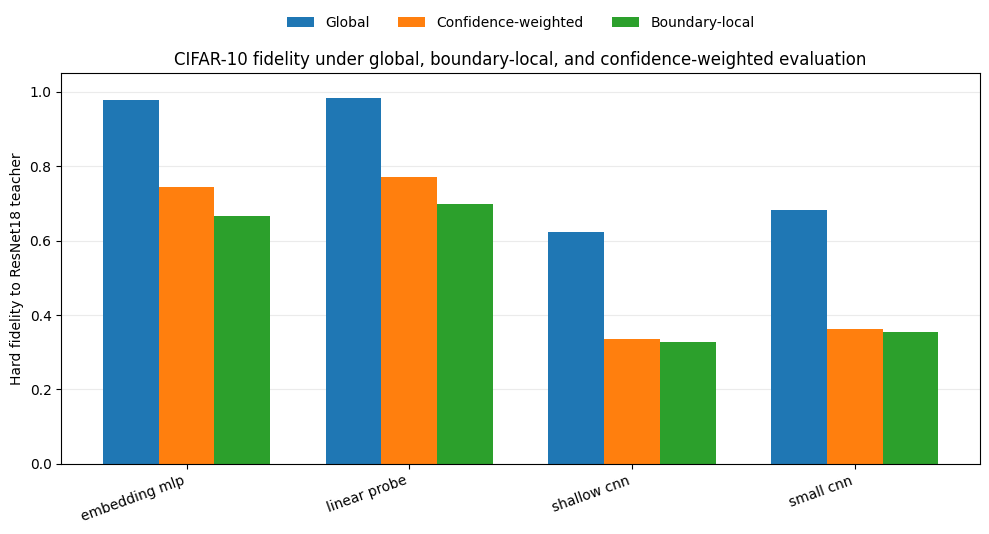

In [20]:
# -----------------------------------------------------------------------------
# Plot 1: CIFAR global vs boundary vs confidence-weighted fidelity
# -----------------------------------------------------------------------------

plot_df = results.sort_values("surrogate")
positions = np.arange(len(plot_df))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5.5), facecolor="white")
ax.set_facecolor("white")

ax.bar(
    positions - width,
    plot_df["global_fidelity"],
    width,
    label="Global",
)
ax.bar(
    positions,
    plot_df["confidence_weighted_fidelity"],
    width,
    label="Confidence-weighted",
)
ax.bar(
    positions + width,
    plot_df["boundary_fidelity"],
    width,
    label="Boundary-local",
)

ax.set_xticks(positions)
ax.set_xticklabels([s.replace("_", " ") for s in plot_df["surrogate"]], rotation=20, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Hard fidelity to ResNet18 teacher")
ax.set_title("CIFAR-10 fidelity under global, boundary-local, and confidence-weighted evaluation")
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.18), ncol=3, frameon=False)

fig.tight_layout()
savefig("cifar_global_boundary_confidence_weighted.png")
plt.show()


Saved ./cifar_artifacts/cifar_confidence_stratified_fidelity.png


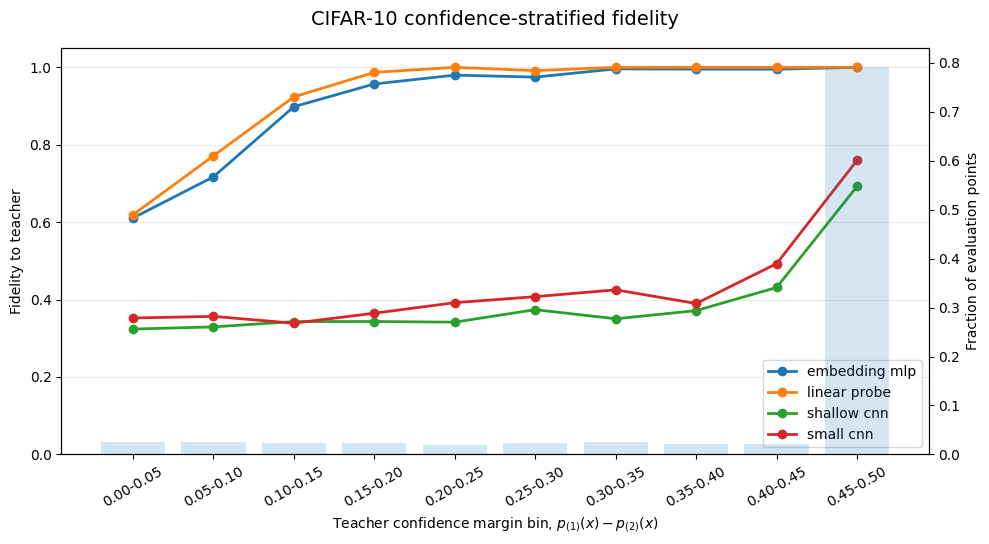

In [21]:
# -----------------------------------------------------------------------------
# Plot 2: CIFAR confidence-stratified fidelity
# -----------------------------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(10, 5.5), facecolor="white")
ax1.set_facecolor("white")

for surrogate_name in sorted(confidence_bins["surrogate"].unique()):
    subset = confidence_bins[confidence_bins["surrogate"] == surrogate_name].sort_values("bin_left")
    ax1.plot(
        subset["bin"],
        subset["fidelity"],
        marker="o",
        linewidth=2,
        label=surrogate_name.replace("_", " "),
    )

ax2 = ax1.twinx()
fraction_subset = confidence_bins.groupby("bin", as_index=False).agg(
    bin_left=("bin_left", "first"),
    fraction=("fraction", "mean"),
).sort_values("bin_left")

ax2.bar(
    fraction_subset["bin"],
    fraction_subset["fraction"],
    alpha=0.18,
    width=0.8,
)

ax1.set_ylim(0, 1.05)
ax1.set_xlabel(r"Teacher confidence margin bin, $p_{(1)}(x)-p_{(2)}(x)$")
ax1.set_ylabel("Fidelity to teacher")
ax2.set_ylabel("Fraction of evaluation points")
ax1.tick_params(axis="x", rotation=30)
ax1.grid(axis="y", alpha=0.25)
ax1.set_axisbelow(True)
ax1.legend(loc="lower right", frameon=True)
fig.suptitle("CIFAR-10 confidence-stratified fidelity", fontsize=14)
fig.tight_layout()
savefig("cifar_confidence_stratified_fidelity.png")
plt.show()


In [22]:
print("Teacher test accuracy:", teacher_metrics["accuracy"])
print("Boundary fraction:", float((test_teacher_data["teacher_margin"] <= BOUNDARY_EPS).mean()))
print("Saved artifacts in:", ARTIFACT_DIR)


Teacher test accuracy: 0.7815
Boundary fraction: 0.0502
Saved artifacts in: ./cifar_artifacts


In [23]:
# Notes for interpretation:
#
# 1. If global fidelity > boundary-local fidelity for most surrogates, the
#    synthetic/tabular phenomenon survives in a modern neural image setting.
#
# 2. If confidence-weighted fidelity falls between global and boundary-local
#    fidelity, then the weighted framework behaves analogously to earlier
#    experiments.
#
# 3. If surrogate rankings differ between global and confidence-weighted fidelity,
#    this creates a natural downstream utility experiment: evaluate whether the
#    confidence-selected surrogate better preserves teacher behavior in low-margin
#    regions.
